<a href="https://colab.research.google.com/github/NathanMagno/energy-consumers-data/blob/ex-36-40/cp04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, silhouette_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


import warnings
warnings.filterwarnings('ignore')

Convertendo o dataset em um dataframe pandas

In [ ]:
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)

1 - Mostrando as 10 primeiras linhas do data frame

In [ ]:
df.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


2 - A Global_active_power é a potência que realiza trabalho útil, convertida em calor, luz ou movimento pelos aparelhos, é o que você paga na conta de luz. Já a Global_reactive_power é a energia que circula em equipamentos como motores e transformadores para criar campos necessários ao seu funcionamento, mas não realiza trabalho útil diretamente. Ou seja, potência ativa faz o trabalho, enquanto a reativa é um suporte para certas cargas.

3 - Valores faltantes



In [ ]:
df.isna().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


4 - Conversão de date para DateTime

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day_of_Week'] = df['Date'].dt.day_name()
display(df.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
0,2006-12-16,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,Saturday
1,2006-12-16,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,Saturday
2,2006-12-16,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,Saturday
3,2006-12-16,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,Saturday
4,2006-12-16,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,Saturday


5 - Filtrar registros e calculo de média

In [ ]:
''' filtre os regristros apenas do ano de 2007  '''
df_2007 = df[df['Date'].dt.year == 2007]
df_2007

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Day_of_Week
21996,2007-01-01,00:00:00,2.580,0.136,241.970,10.600,0.000,0.000,0.0,Monday
21997,2007-01-01,00:01:00,2.552,0.100,241.750,10.400,0.000,0.000,0.0,Monday
21998,2007-01-01,00:02:00,2.550,0.100,241.640,10.400,0.000,0.000,0.0,Monday
21999,2007-01-01,00:03:00,2.550,0.100,241.710,10.400,0.000,0.000,0.0,Monday
22000,2007-01-01,00:04:00,2.554,0.100,241.980,10.400,0.000,0.000,0.0,Monday
...,...,...,...,...,...,...,...,...,...,...
547591,2007-12-31,23:55:00,1.746,0.204,242.410,7.200,0.000,0.000,18.0,Monday
547592,2007-12-31,23:56:00,1.732,0.210,242.420,7.200,0.000,0.000,18.0,Monday
547593,2007-12-31,23:57:00,1.732,0.210,242.500,7.200,0.000,0.000,18.0,Monday
547594,2007-12-31,23:58:00,1.684,0.144,242.180,7.000,0.000,0.000,18.0,Monday


In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df_2007['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  object        
 4   Voltage                object        
 5   Global_intensity       object        
 6   Sub_metering_1         object        
 7   Sub_metering_2         object        
 8   Sub_metering_3         float64       
 9   Day_of_Week            object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 158.3+ MB


In [ ]:
df_2007.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525600 entries, 21996 to 547595
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   525600 non-null  datetime64[ns]
 1   Time                   525600 non-null  object        
 2   Global_active_power    521669 non-null  float64       
 3   Global_reactive_power  525600 non-null  object        
 4   Voltage                525600 non-null  object        
 5   Global_intensity       525600 non-null  object        
 6   Sub_metering_1         525600 non-null  object        
 7   Sub_metering_2         525600 non-null  object        
 8   Sub_metering_3         521669 non-null  float64       
 9   Day_of_Week            525600 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 44.1+ MB


In [ ]:
media = df_2007.groupby('Date')['Global_active_power'].mean()
display(media)

,Global_active_power
Date,
2007-01-01,1.909031
2007-01-02,0.881414
2007-01-03,0.704204
2007-01-04,2.263481
2007-01-05,1.884281
...,...
2007-12-27,1.758471
2007-12-28,2.161842
2007-12-29,2.290942


6 - Gráfica de variação de global active power

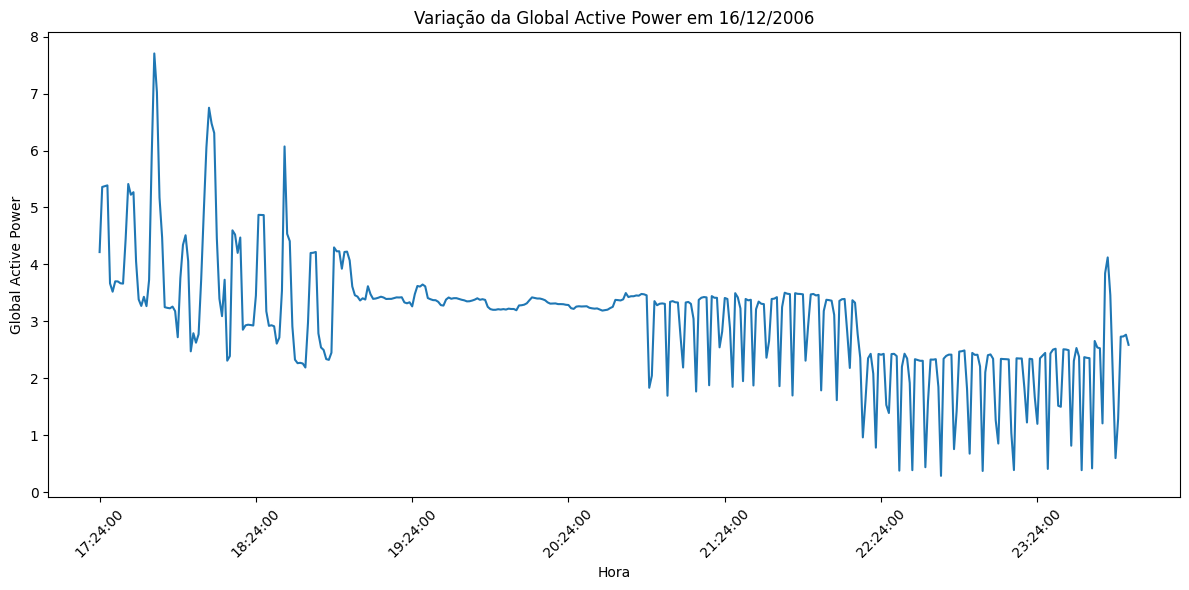

In [ ]:
# Gerar um gráfico de linha com seaborn que mostra a variação da feature Global_ative_power em um único dia

first_day = df['Date'].min()
df_one_day = df[df['Date'] == first_day]

plt.figure(figsize=(12, 6))
sb.lineplot(data=df_one_day, x='Time', y='Global_active_power')
plt.title(f'Variação da Global Active Power em {first_day.strftime("%d/%m/%Y")}')
plt.xlabel('Hora')
plt.ylabel('Global Active Power')
plt.xticks(df_one_day['Time'][::60], rotation=45) # Show ticks every 60 minutes
plt.tight_layout()
plt.show()

 7. Crie um histograma da variável Voltage. O que pode ser observado sobre sua distribuição?

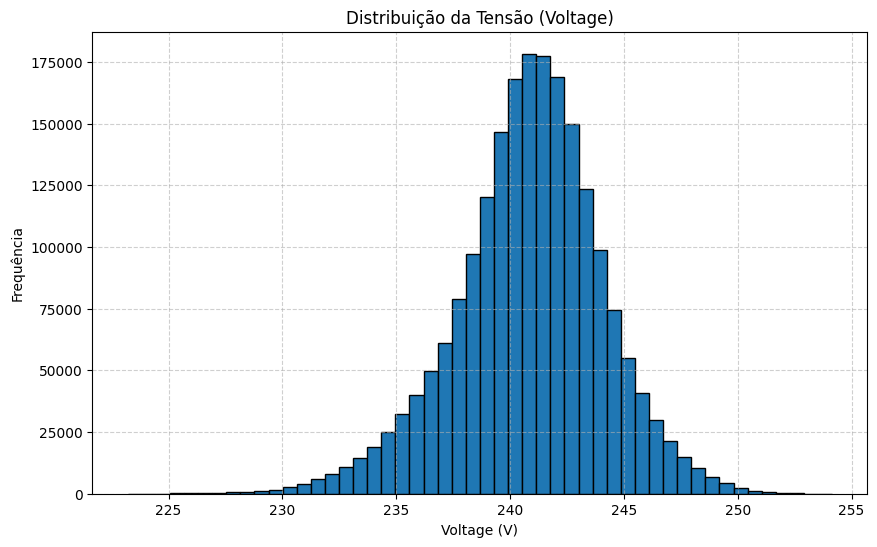

In [ ]:
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

plt.figure(figsize=(10,6))
plt.hist(df['Voltage'].dropna(), bins=50, edgecolor='black')
plt.title('Distribuição da Tensão (Voltage)')
plt.xlabel('Voltage (V)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

A distribuição do Voltage é aproximadamente normal, concentrada em torno de 240V, mostrando estabilidade na rede elétrica com pequenas variações e poucos valores extremos.

 8. Calcule o consumo médio por mês em todo o período disponível no dataset.


In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

df['YearMonth'] = df['Date'].dt.to_period('M')
media_mensal = df.groupby('YearMonth')['Global_active_power'].mean()

display(media_mensal)

,Global_active_power
YearMonth,
2006-12,1.901295
2007-01,1.546034
2007-02,1.401084
2007-03,1.318627
2007-04,0.891189
2007-05,0.985862
2007-06,0.826814
2007-07,0.667367
2007-08,0.764186


9. Identifique o dia com maior consumo de energia ativa global (Global_active_power).

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

consumo_dia = df.groupby('Date')['Global_active_power'].sum()

dia_max = consumo_dia.idxmax()
valor_max = consumo_dia.max()

print(f"O dia de maior consumo foi {dia_max.strftime('%d/%m/%Y')} com {valor_max:.2f} kW")

O dia de maior consumo foi 23/12/2006 com 4773.39 kW


10. Compare o consumo médio de energia ativa global em dias de semana versus finais de
 semana.

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

media_semana_vs_fim = df.groupby(df['Day_of_Week'].isin(['Saturday', 'Sunday']).map({False: 'Dias de semana', True: 'Fins de semana'}))['Global_active_power'].mean()

print(media_semana_vs_fim)

Day_of_Week
Dias de semana    1.035472
Fins de semana    1.234232
Name: Global_active_power, dtype: float64


11 - Calcule a correlação entre as variáveis Global_active_power, Global_reactive_power, Voltage e Global_intensity.

In [ ]:

cols_to_numeric = ['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

correlation = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].corr()
display(correlation)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity
Global_active_power,1.000000,0.247017,-0.399762,0.998889
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120
Voltage,-0.399762,-0.112246,1.000000,-0.411363
Global_intensity,0.998889,0.266120,-0.411363,1.000000


12 - Crie uma nova variável chamada Total_Sub_metering que some Sub_metering_1, Sub_metering_2 e Sub_metering_3.

In [ ]:
df['Total_Sub_metering'] = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
display(df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Total_Sub_metering']].head())

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Total_Sub_metering
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


13 - Verifique se há algum mês em que Total_Sub_metering ultrapassa a média de Global_active_power.

In [ ]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['Global_active_power', 'Total_Sub_metering']].mean()

display(monthly_avg)

months_exceeding_average = monthly_avg[monthly_avg['Total_Sub_metering'] > monthly_avg['Global_active_power']]

if not months_exceeding_average.empty:
    print("\nMonths where Total_Sub_metering exceeds the average Global_active_power:")
    display(months_exceeding_average)
else:
    print("\nThere are no months where Total_Sub_metering exceeds the average Global_active_power.")


,Global_active_power,Total_Sub_metering
Month,,
1,1.462226,10.749374
2,1.300431,10.106044
3,1.231343,9.856913
4,1.047146,8.927079
5,1.029571,9.239570
6,0.909148,8.747352
7,0.700359,5.975636
8,0.572812,5.170673
9,0.975653,8.697096



Months where Total_Sub_metering exceeds the average Global_active_power:


,Global_active_power,Total_Sub_metering
Month,,
1,1.462226,10.749374
2,1.300431,10.106044
3,1.231343,9.856913
4,1.047146,8.927079
5,1.029571,9.239570
6,0.909148,8.747352
7,0.700359,5.975636
8,0.572812,5.170673
9,0.975653,8.697096


14 - Faça um gráfico de série temporal do Voltage para o ano de 2008.

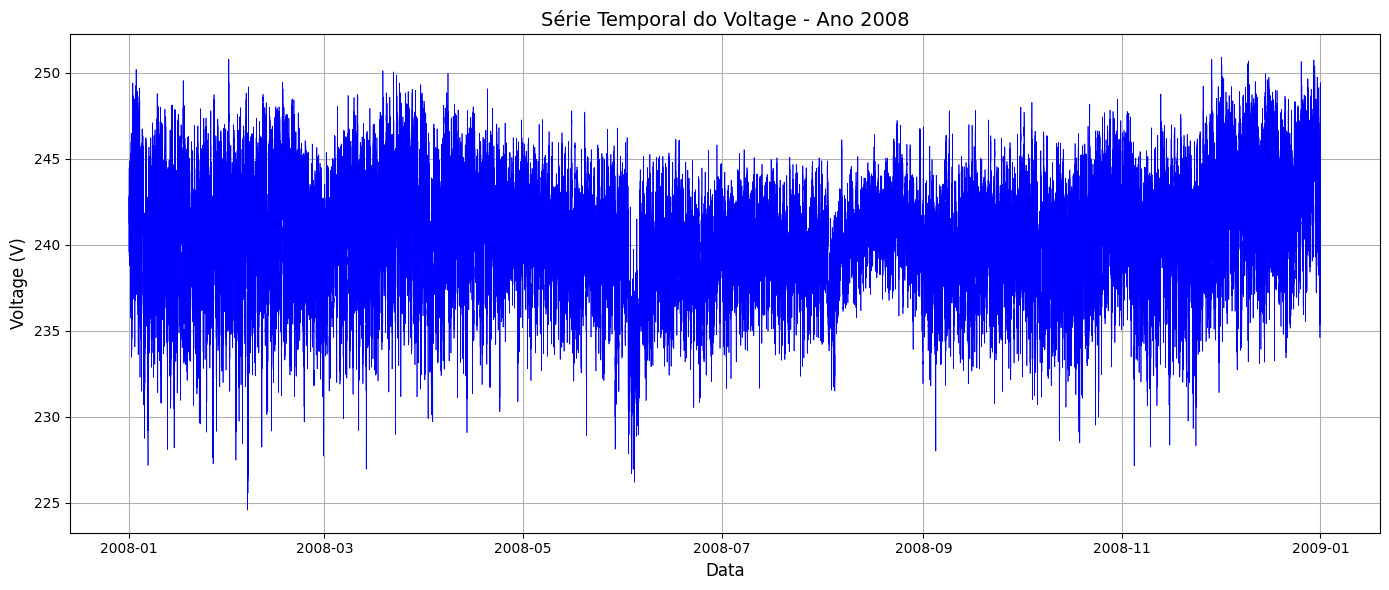

In [ ]:
# Converter Date e Time para datetime
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'],
                                 format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Converter Voltage para numérico
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')

# Filtrar apenas o ano de 2008
df_2008 = df[df['DateTime'].dt.year == 2008]

# Plotar gráfico de série temporal
plt.figure(figsize=(14,6))
plt.plot(df_2008['DateTime'], df_2008['Voltage'], color='blue', linewidth=0.5)

plt.title("Série Temporal do Voltage - Ano 2008", fontsize=14)
plt.xlabel("Data", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

15 - Compare o consumo entre os meses de verão e inverno (no hemisfério norte).

In [ ]:
summer_months = [6, 7, 8]  # June, July, August
winter_months = [12, 1, 2] # December, January, February

summer_consumption = df[df['Month'].isin(summer_months)]['Global_active_power'].mean()
winter_consumption = df[df['Month'].isin(winter_months)]['Global_active_power'].mean()

print(f"Average Global Active Power in Summer (Northern Hemisphere): {summer_consumption:.2f}")
print(f"Average Global Active Power in Winter (Northern Hemisphere): {winter_consumption:.2f}")

if summer_consumption > winter_consumption:
    print("\nAverage power consumption is higher in summer than in winter.")
elif winter_consumption > summer_consumption:
    print("\nAverage power consumption is higher in winter than in summer.")
else:
    print("\nAverage power consumption is similar in summer and winter.")

Average Global Active Power in Summer (Northern Hemisphere): 0.73
Average Global Active Power in Winter (Northern Hemisphere): 1.42

Average power consumption is higher in winter than in summer.


16 - Aplique uma amostragem aleatória de 1% dos dados e verifique se a distribuição de Global_active_power é semelhante à da base completa.

In [ ]:
# base completa

media_base_completa = df['Global_active_power'].mean()
mediana_base_completa = df['Global_active_power'].median()
desvio_padrao_base_completa = df['Global_active_power'].std()

print(f"Média da base completa: {media_base_completa:.2f}")
print(f"Mediana da base completa: {mediana_base_completa:.2f}")
print(f"Desvio padrão da base completa: {desvio_padrao_base_completa:.2f}")

Média da base completa: 1.09
Mediana da base completa: 0.60
Desvio padrão da base completa: 1.06


In [ ]:
# amostragem aleatória de 1% dos dados

df_amostra = df.sample(frac=0.01, random_state=10)
media_amostra = df_amostra['Global_active_power'].mean()
mediana_amostra = df_amostra['Global_active_power'].median()
desvio_padrao_amostra = df_amostra['Global_active_power'].std()

print(f"Média da amostra: {media_amostra:.2f}")
print(f"Mediana da amostra: {mediana_amostra:.2f}")
print(f"Desvio padrão da amostra: {desvio_padrao_amostra:.2f}")

Média da amostra: 1.09
Mediana da amostra: 0.62
Desvio padrão da amostra: 1.04


17 - Utilize uma técnica de normalização (Min-Max Scaling) para padronizar as variáveis numéricas principais.

In [ ]:
# selecionando as colunas numéricas

colunas_numericas = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# normalização

scaler = MinMaxScaler()
df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

display(df[colunas_numericas].head())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.374796,0.300719,0.376090,0.377593,0.0,0.0125,0.548387
1,0.478363,0.313669,0.336995,0.473029,0.0,0.0125,0.516129
2,0.479631,0.358273,0.326010,0.473029,0.0,0.0250,0.548387
3,0.480898,0.361151,0.340549,0.473029,0.0,0.0125,0.548387
4,0.325005,0.379856,0.403231,0.323651,0.0,0.0125,0.548387


18 - Aplique K-means para segmentar os dias em 3 grupos distintos de consumo elétrico. Interprete os resultados.

In [ ]:
# Conta o total de valores NaN por coluna
print("Contagem de valores NaN por coluna:")
print(df.isnull().sum())

# Conta a porcentagem de valores NaN na coluna 'Global_active_power'
global_power_nan_percent = (df['Global_active_power'].isnull().sum() / len(df)) * 100
print(f"\nPorcentagem de NaN na coluna 'Global_active_power': {global_power_nan_percent:.2f}%")

Contagem de valores NaN por coluna:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Day_of_Week                  0
YearMonth                    0
Total_Sub_metering       25979
Month                        0
DateTime                     0
dtype: int64

Porcentagem de NaN na coluna 'Global_active_power': 1.25%


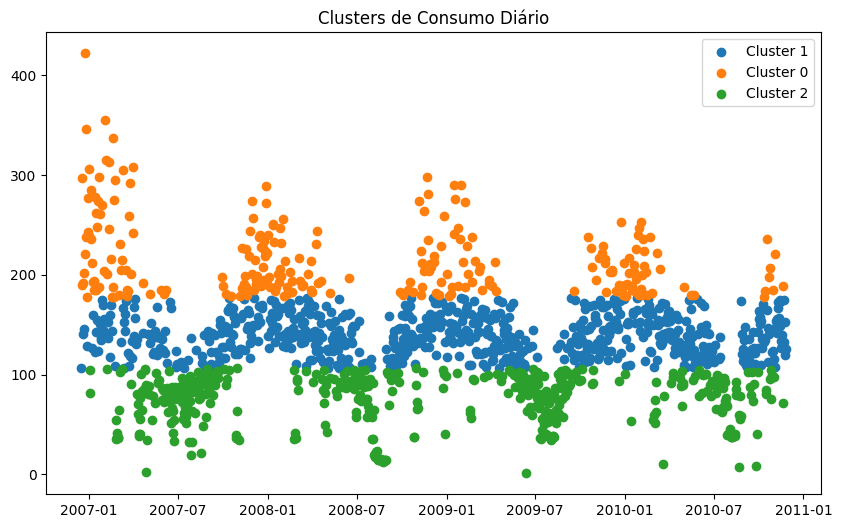

In [ ]:
df = df.dropna(subset=['Global_active_power'])
diario = df.groupby('Date')['Global_active_power'].sum().reset_index()
kmeans = KMeans(n_clusters=3)
diario['cluster'] = kmeans.fit_predict(diario[['Global_active_power']])


# Visualizar clusters
plt.figure(figsize=(10,6))
for c in diario['cluster'].unique():
    plt.scatter(diario[diario['cluster']==c]['Date'],
                diario[diario['cluster']==c]['Global_active_power'], label=f'Cluster {c}')
plt.legend()
plt.title("Clusters de Consumo Diário")
plt.show()

In [ ]:
# INTERPRETAÇÕES

# Pontos verdes: Este grupo representa os dias em que o consumo de energia elétrica foi consistentemente o mais baixo.
# Provavelmente são dias de feriado, fins de semana, férias.

# Pontos laranjas: Este grupo engloba os dias de consumo considerado "normal" ou "típico".
# É o grupo mais denso e representa a maioria dos dias, possivelmente os dias de semana em que o consumo segue um padrão regular.

# (pontos em azul): Este grupo é formado pelos dias com o maior consumo de energia.
# Eles podem corresponder a períodos de uso intensivo de eletrodomésticos,
# uso de aquecedores ou ar-condicionado em dias de clima extremo, ou eventos especiais que demandaram mais energia.

19 - Realize uma decomposição de série temporal (tendência, sazonalidade e resíduo) para Global_active_power em um período de 6 meses.

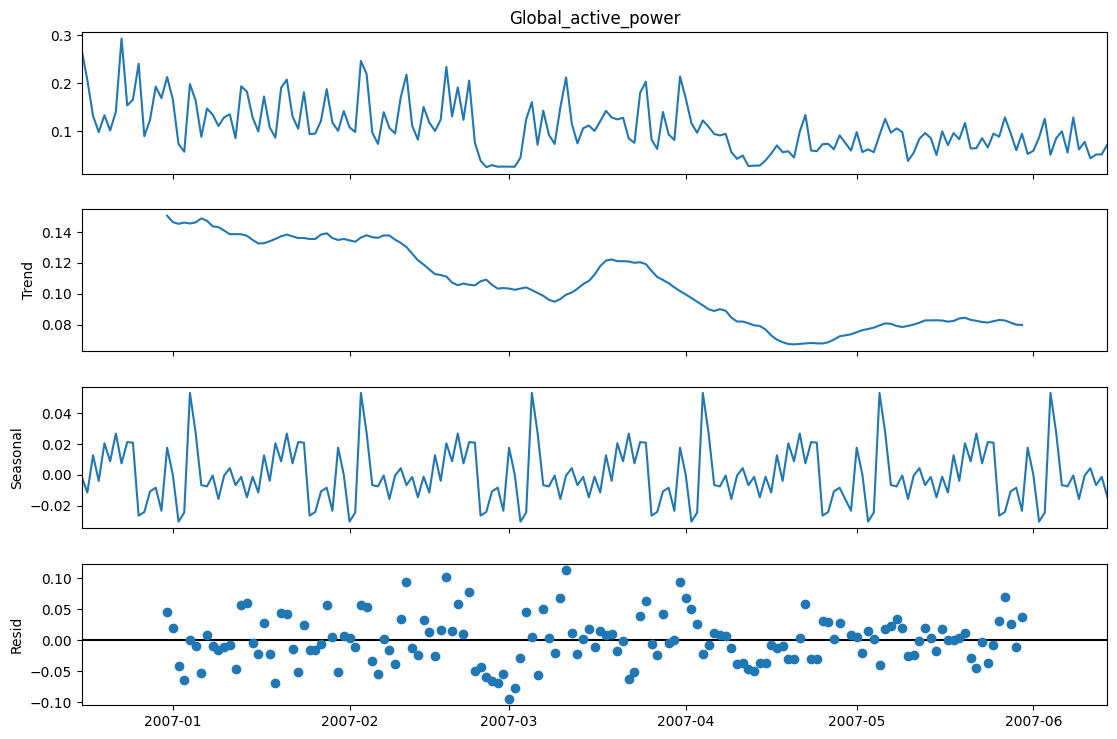

In [ ]:
seis_meses = df.set_index('Date').resample('D')['Global_active_power'].mean().dropna().iloc[:180]

# Decomposição
decomp = seasonal_decompose(seis_meses, model='additive', period=30)  # período -> mensal
fig = decomp.plot()
fig.set_size_inches(12,8)
plt.show()

20 - Treine um modelo de regressão linear simples para prever Global _active_power a partir de Global_intensity. Avalie o erro do modelo.

In [ ]:
X = df[['Global_intensity']]
y = df['Global_active_power']

X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

# avaliação
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 0.004486110635023933
R²: 0.9978152308016333


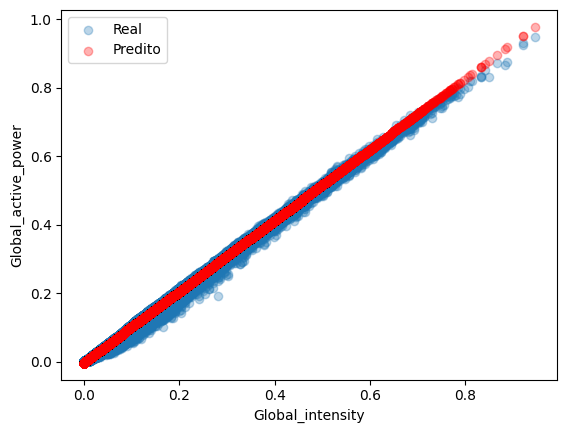

In [ ]:
plt.scatter(X_test, y_test, alpha=0.3, label="Real")
plt.scatter(X_test, y_pred, color='red', alpha=0.3, label="Predito")
plt.xlabel("Global_intensity")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

In [ ]:
# INTERPRETAÇÃO

# com um R² de 0,998, praticamente toda a variação de Global_active_power pode ser explicada por Global_intensity. O erro médio das previsões foi muito baixo (RMSE ≈ 0,0053)
# isso indica que o modelo tem excelente capacidade de previsão e que existe uma relação linear muito forte entre essas duas variáveis


21 - Séries temporais por hora - Converta Date e Time em índice datetime. - Reamostre os dados em intervalos de 1 hora, calculando a média de Global_active_power. - Identifique os horários de maior consumo médio ao longo do dia. Observação: uma série temporal é um conjunto de dados registrados em ordem cronológica, útil para identificar padrões de comportamento ao longo do tempo.

In [ ]:
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])

df = df.set_index('DateTime')
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

consumo_horario = df['Global_active_power'].resample('h').mean()

display(consumo_horario.head(10))
consumo_por_hora = consumo_horario.groupby(consumo_horario.index.hour).mean()

print(consumo_por_hora)

hora_max = consumo_por_hora.idxmax()
valor_max = consumo_por_hora.max()

print(f"Horário de maior consumo médio: {hora_max}:00 com {valor_max:.2f} kW")

,Global_active_power
DateTime,
2006-12-16 17:00:00,0.375420
2006-12-16 18:00:00,0.321945
2006-12-16 19:00:00,0.300945
2006-12-16 20:00:00,0.289025
2006-12-16 21:00:00,0.269823
2006-12-16 22:00:00,0.192299
2006-12-16 23:00:00,0.179757
2006-12-17 00:00:00,0.163540
2006-12-17 01:00:00,0.296343


DateTime
0     0.052830
1     0.041945
2     0.036630
3     0.033392
4     0.033301
5     0.034191
6     0.064784
7     0.129130
8     0.125379
9     0.113674
10    0.107271
11    0.105958
12    0.102396
13    0.096729
14    0.091142
15    0.082818
16    0.079016
17    0.088735
18    0.113202
19    0.150048
20    0.165044
21    0.162961
22    0.121010
23    0.074791
Name: Global_active_power, dtype: float64
Horário de maior consumo médio: 20:00 com 0.17 kW


22 - Autocorrelação do consumo - Use a série temporal de Global_active_power. - Calcule a autocorrelação em lags de 1h, 24h e 48h. - Pergunta: existem padrões repetidos diariamente?


In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
df = df.set_index('DateTime')

consumo_horario = df['Global_active_power'].resample('h').mean()

lag_1h = consumo_horario.autocorr(lag=1)
lag_24h = consumo_horario.autocorr(lag=24)
lag_48h = consumo_horario.autocorr(lag=48)

print("Autocorrelação 1h:", lag_1h)
print("Autocorrelação 24h:", lag_24h)
print("Autocorrelação 48h:", lag_48h)

Autocorrelação 1h: 0.713455594691645
Autocorrelação 24h: 0.43590722591199127
Autocorrelação 48h: 0.4012692620450157


Se o valor de autocorrelação em 24h for alto e positivo (próximo de 1 ou pelo menos acima de aprox 0.5), isso indica que o consumo apresenta padrões repetidos diariamente. O valor em 48h geralmente reforça esse comportamento, mas tende a ser um pouco menor que o de 24h.

23 - Redução de dimensionalidade com PCA - Selecione Global_active_power, Global_reactive_power, Voltage e Global_intensity. - Aplique PCA para reduzir para 2 componentes principais. - Analise a variância explicada por cada componente.

In [ ]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['Global_reactive_power'] = pd.to_numeric(df['Global_reactive_power'], errors='coerce')
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')
df['Global_intensity'] = pd.to_numeric(df['Global_intensity'], errors='coerce')

X = df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
print("Variância explicada por cada componente:", explained_var)
print("Variância total explicada (2 componentes):", explained_var.sum())

Variância explicada por cada componente: [0.59103759 0.22718543]
Variância total explicada (2 componentes): 0.8182230176077278


24 - Visualização de clusters no espaço PCA - Combine os resultados do PCA com K-Means (3 clusters). - Plote os pontos resultantes e pinte cada grupo por cluster. - Pergunta: os grupos se separam de forma clara?

<Axes: xlabel='PC1', ylabel='PC2'>

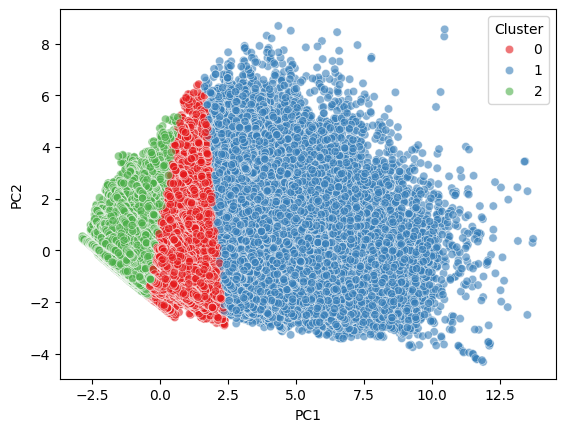

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters

sb.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set1', alpha=0.6)

Se os clusters aparecem bem separados no gráfico, significa que os dados possuem estruturas naturais distintas (boa separação).

Se houver sobreposição forte entre cores, então os clusters não estão bem definidos, e pode ser necessário aumentar o número de variáveis no PCA ou ajustar o número de clusters.

25 - Regressão polinomial vs linear - Modele Global_active_power em função de Voltage. - Compare Regressão Linear Simples com Regressão Polinomial (grau 2). - Analise RMSE e a curva ajustada.

RMSE - Linear: 0.0877
RMSE - Polinomial (grau 2): 0.0873


<Axes: xlabel='Voltage', ylabel='Global_active_power'>

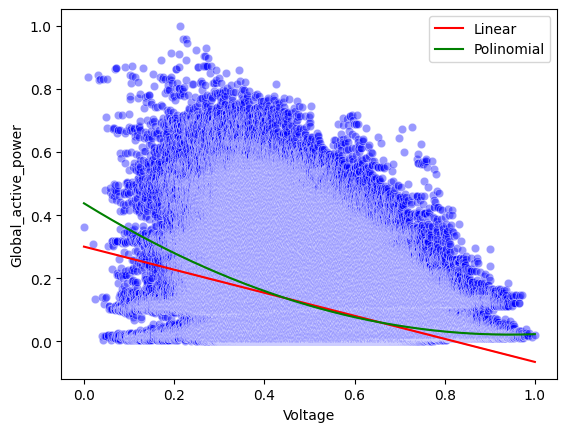

In [ ]:
df["Voltage"] = pd.to_numeric(df["Voltage"], errors="coerce")
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

df_model = df[["Voltage", "Global_active_power"]].dropna()

X = df_model[["Voltage"]]
y = df_model["Global_active_power"]

linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print(f"RMSE - Linear: {rmse_linear:.4f}")
print(f"RMSE - Polinomial (grau 2): {rmse_poly:.4f}")

df_plot = df_model.copy()
df_plot["Linear"] = y_pred_linear
df_plot["Polinomial"] = y_pred_poly

df_plot = df_plot.sort_values("Voltage")

sb.scatterplot(x="Voltage", y="Global_active_power", data=df_plot, color="blue", alpha=0.4)
sb.lineplot(x="Voltage", y="Linear", data=df_plot, color="red", label="Linear")
sb.lineplot(x="Voltage", y="Polinomial", data=df_plot, color="green", label="Polinomial")

26 -  Carregamento e inspeção inicial do DataSet

In [ ]:
# Carregando dataSet com pandas
apc_df = pd.read_csv("/content/energydata_complete.csv", sep=',' , low_memory = False)

In [ ]:
# Listando tipos de dados
apc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [ ]:
# Listando informações estatísicas das features numéricas do dataset
apc_df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


27 - Distribuição do consumo

<Axes: >

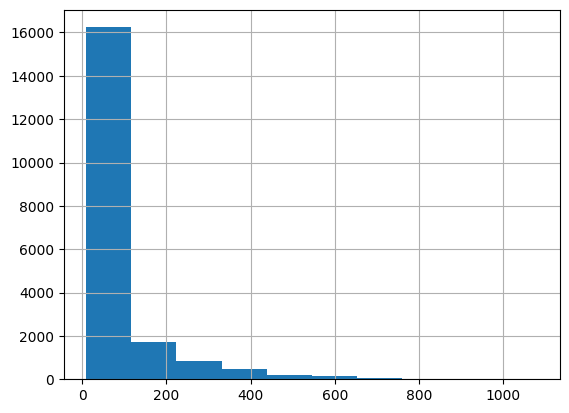

In [ ]:
apc_df['Appliances'].hist()

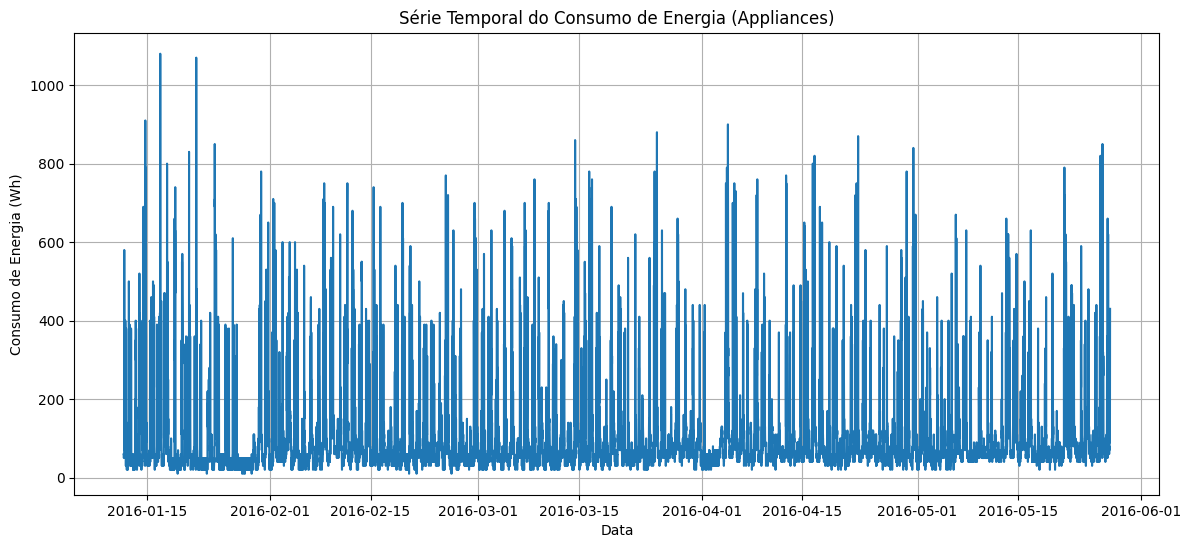

In [ ]:
apc_df['date'] = pd.to_datetime(apc_df['date'])

plt.figure(figsize=(14, 6))
sb.lineplot(data=apc_df, x='date', y='Appliances')
plt.title('Série Temporal do Consumo de Energia (Appliances)')
plt.xlabel('Data')
plt.ylabel('Consumo de Energia (Wh)')
plt.grid(True)
plt.show()

28 - Correlações com variáveis ambientais

In [ ]:
correlations = apc_df[['Appliances', 'T1', 'RH_1', 'T2', 'RH_2']].corr()

display(correlations)

,Appliances,T1,RH_1,T2,RH_2
Appliances,1.000000,0.055447,0.086031,0.120073,-0.060465
T1,0.055447,1.000000,0.164006,0.836834,-0.002509
RH_1,0.086031,0.164006,1.000000,0.269839,0.797535
T2,0.120073,0.836834,0.269839,1.000000,-0.165610
RH_2,-0.060465,-0.002509,0.797535,-0.165610,1.000000


Explicando a relação dessas features com o consumo:

'T1' (Temperatura na cozinha) tem uma correlação positiva baixa (0.055). Isso quer dizer que, em geral, um pequeno aumento na temperatura da cozinha está associado a um pequeno aumento no consumo, mas a relação é fraca.

'RH_1' (Umidade na cozinha) tem uma correlação positiva um pouco maior que T1 (0.086). Um pouco mais de umidade na cozinha parece ter uma relação um pouco mais forte com o aumento do consumo do que a temperatura da cozinha, mas ainda é uma relação fraca.

'T2' (Temperatura na sala de estar/área de serviço) tem a maior correlação positiva (0.120) entre essas variáveis. Um aumento na temperatura dessa área tem a associação linear mais notável com o aumento do consumo, comparado às outras variáveis analisadas, mas ainda é considerada uma correlação fraca.

'RH_2' (Umidade na sala de estar/área de serviço) tem uma correlação negativa baixa (-0.060). Isso sugere que, conforme a umidade nessa área aumenta, o consumo tende a diminuir um pouco, mas essa relação também é muito fraca.

29 - Normalização dos dados

In [ ]:
numerical_cols = apc_df.select_dtypes(include=['float64', 'int64']).columns

scaler = MinMaxScaler()

apc_df[numerical_cols] = scaler.fit_transform(apc_df[numerical_cols])

display(apc_df.head())

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,0.046729,0.428571,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,...,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449
1,2016-01-11 17:10:00,0.046729,0.428571,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,...,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083
2,2016-01-11 17:20:00,0.037383,0.428571,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,...,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848
3,2016-01-11 17:30:00,0.037383,0.571429,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,...,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261
4,2016-01-11 17:40:00,0.046729,0.571429,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,...,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611


30 - Aplicar PCA

In [ ]:
# Reduzindo para dois componentes principais
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

apc_df_pca = pca.fit_transform(apc_df.select_dtypes(include=['float64', 'int64']))

# Criar um novo DataFrame com os componentes principais
apc_df_pca = pd.DataFrame(apc_df_pca, columns=['Component_1', 'Component_2'])

display(apc_df_pca.head())

,Component_1,Component_2
0,0.723991,0.596281
1,0.724805,0.592120
2,0.728731,0.577034
3,0.743361,0.566725
4,0.734231,0.562557


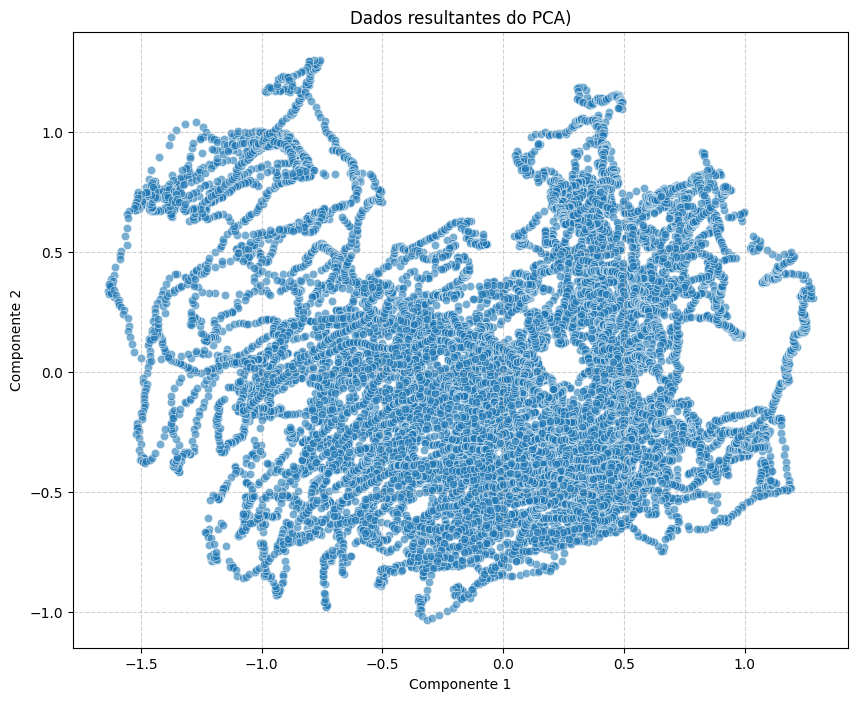

In [ ]:
# Plote dos resultados do PCA
plt.figure(figsize=(10, 8))
sb.scatterplot(data=apc_df_pca, x='Component_1', y='Component_2', alpha=0.6)
plt.title('Dados resultantes do PCA)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Aparecem Padrões ou agrupamentos naturais?

Ao observar o gráfico de dispersão dos resultados do PCA, que projeta os dados em dois componentes principais, nota-se que não emergem padrões ou agrupamentos naturais bem definidos.

Os pontos no gráfico exibem uma distribuição dispersa, formando uma estrutura contínua em vez de clusters distintos. Com base na representação em duas dimensões obtida pelo PCA, não há evidências visuais de grupos homogêneos ou subdivisões claras dentro do conjunto de dados analisado. Portanto, não há evidências visuais de agrupamentos naturais ou subdivisões claras dentro do conjunto de dados analisado.

31 - Regressão Linear Múltipla
Modele Appliances em função das variáveis ambientais.
Avalie Rz e erro médio.

In [ ]:
# selecionando as variáveis -> excluindo date (irrelevante para regressão) e lights (não é ambiental)

X = apc_df.drop(columns=["Appliances", "date", "lights"])
y = apc_df["Appliances"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predição
y_pred = model.predict(X_test)

In [ ]:
# Avaliando o Modelo
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"O R² (Coeficiente de Determinação) é: {r2:.2f}")
print(f"O MAE (Erro Médio Absoluto) é: {mae:.2f}")

O R² (Coeficiente de Determinação) é: 0.15
O MAE (Erro Médio Absoluto) é: 0.05


O modelo linear explica pouco (R² = 0.15) -> ou seja, não é tão bom para prever consumo de energia apenas com variáveis ambientais.

Erro médio baixo (MAE = 0.05) -> pode ser enganoso, pois depende da escala dos dados.

In [ ]:
# RMSE da regressão linear

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE Regressão Linear: {rmse_lr:.4f}")

RMSE Regressão Linear: 0.0864


32 - Random Forest Regressor

Treine um modelo de Random Forest para prever Appliances.
Compare o RMSE com a regressão linear.

In [ ]:
# Treinando o modelo Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
# RMSE do Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE Random Forest: {rmse_rf:.4f}")

RMSE Random Forest: 0.0598


In [ ]:
print(f"RMSE - Random Forest: {rmse_rf:.4f}")
print(f"RMSE - Regressão Linear: {rmse_lr:.4f}")

RMSE - Random Forest: 0.0598
RMSE - Regressão Linear: 0.0864


In [ ]:
# Como o RMSE mede o erro médio das previsões em relação aos valores reais (em unidades da variável Appliances),
#quanto menor, melhor o modelo está prevendo.

#O Random Forest, que combina várias árvores de decisão,
#conseguiu reduzir bastante o erro porque se adapta melhor a relações complexas entre as variáveis.

# Isso indica que o Random Forest
#conseguiu capturar melhor as relações entre as variáveis e produzir previsões mais precisas.

33 - K-Means clustering

Aplique K-Means com 3 a 5 clusters.
Interprete os perfis de consumo.

In [ ]:
apc_df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [ ]:
dados = apc_df.drop(columns=["date", "lights", "Appliances"])
dados.head()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,0.175506,0.381691,...,0.223032,0.677290,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449
1,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,0.175506,0.381691,...,0.226500,0.678532,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083
2,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,0.175506,0.380037,...,0.219563,0.676049,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848
3,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,0.175506,0.380037,...,0.219563,0.671909,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261
4,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,0.178691,0.380037,...,0.219563,0.671909,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611


In [ ]:
distorcoes = []
K = range(1, 11) # Adotando 10 clusters.
for k in K:
    modelo01 = KMeans(n_clusters=k)
    modelo01.fit(dados)    # Treinamos o modelo com o algoritmo K-Means por 10 vezes
    distorcoes.append(modelo01.inertia_)

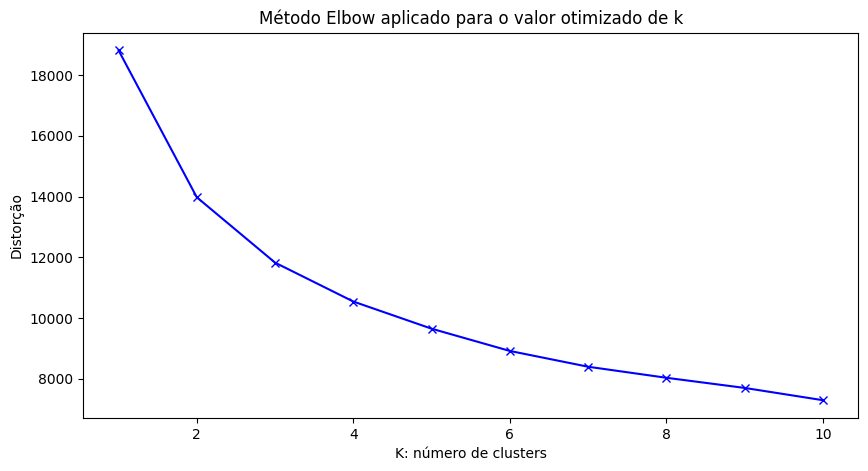

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(K, distorcoes, '-bx')

# Define os labels do eixos do gráfico:
plt.xlabel('K: número de clusters')
plt.ylabel('Distorção')

# Define um título para o gráfico:
plt.title('Método Elbow aplicado para o valor otimizado de k')

# Mostra o gráfico:
plt.show()

In [ ]:
# usando 3 clusters
modelo_3 = KMeans(n_clusters=3)

In [ ]:
modelo_3.fit(dados)

KMeans(n_clusters=3)

In [ ]:
dados['Grupos'] = modelo_3.predict(dados)
dados.head()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Grupos
0,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,0.175506,0.381691,...,0.677290,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449,2
1,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,0.175506,0.381691,...,0.678532,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083,2
2,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,0.175506,0.380037,...,0.676049,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848,2
3,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,0.175506,0.380037,...,0.671909,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261,2
4,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,0.178691,0.380037,...,0.671909,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611,2


In [ ]:
silhouette_3 = silhouette_score(dados, dados['Grupos'])
print(f'Silhouette score: {silhouette_3:.4f}')

Silhouette score: 0.4173


In [ ]:
dados.groupby("Grupos").mean()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
Grupos,,,,,,,,,,,,,,,,,,,,,
0,0.443838,0.296885,0.208514,0.529611,0.348582,0.402367,0.452985,0.362135,0.333512,0.292180,...,0.410517,0.410909,0.285500,0.641735,0.766318,0.230942,0.580434,0.339653,0.503129,0.503129
1,0.691016,0.391750,0.474172,0.554037,0.603157,0.471597,0.718913,0.498472,0.598823,0.300973,...,0.716276,0.518163,0.583293,0.585289,0.599714,0.268179,0.553901,0.622461,0.494367,0.494367
2,0.429015,0.455620,0.280861,0.629955,0.320931,0.677502,0.381518,0.699771,0.297367,0.387889,...,0.296498,0.697353,0.373836,0.581559,0.845767,0.423676,0.589335,0.512630,0.500342,0.500342


In [ ]:
dados.columns

Index(['T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5',
       'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out',
       'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1',
       'rv2', 'Grupos'],
      dtype='object')

In [ ]:
# usando 5 clusters
modelo_5 = KMeans(n_clusters=5)
modelo_5.fit(dados)
dados['Grupos_5'] = modelo_5.predict(dados)

dados.head()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Grupos,Grupos_5
0,0.32735,0.566187,0.225345,0.684038,0.215188,0.746066,0.351351,0.764262,0.175506,0.381691,...,0.372990,0.097674,0.894737,0.500000,0.953846,0.538462,0.265449,0.265449,2,0
1,0.32735,0.541326,0.225345,0.682140,0.215188,0.748871,0.351351,0.782437,0.175506,0.381691,...,0.369239,0.100000,0.894737,0.476190,0.894872,0.533937,0.372083,0.372083,2,0
2,0.32735,0.530502,0.225345,0.679445,0.215188,0.755569,0.344745,0.778062,0.175506,0.380037,...,0.365488,0.102326,0.894737,0.452381,0.835897,0.529412,0.572848,0.572848,2,0
3,0.32735,0.524080,0.225345,0.678414,0.215188,0.758685,0.341441,0.770949,0.175506,0.380037,...,0.361736,0.104651,0.894737,0.428571,0.776923,0.524887,0.908261,0.908261,2,0
4,0.32735,0.531419,0.225345,0.676727,0.215188,0.758685,0.341441,0.762697,0.178691,0.380037,...,0.357985,0.106977,0.894737,0.404762,0.717949,0.520362,0.201611,0.201611,2,0


In [ ]:
silhouette_5 = silhouette_score(dados, dados['Grupos_5'])
print(f'Silhouette score 5 clusters: {silhouette_5:.4f}')

Silhouette score 5 clusters: 0.5457


34 - Classificação binária

Crie uma variável: alto vs baixo consumo (Appliances maior/menor que a mediana).
Treine Logistic Regression e Random Forest Classifier.

In [ ]:
mediana = apc_df['Appliances'].median()
apc_df['Alto_Consumo'] = (apc_df['Appliances'] > mediana).astype(int)

apc_df[['Appliances', 'Alto_Consumo']].head(20)

,Appliances,Alto_Consumo
0,0.046729,0
1,0.046729,0
2,0.037383,0
3,0.037383,0
4,0.046729,0
5,0.037383,0
6,0.046729,0
7,0.046729,0
8,0.046729,0
9,0.056075,1


In [ ]:
# X: variáveis ambientais
X = apc_df.drop(columns=['date', 'lights', 'Appliances', 'Alto_Consumo'])

# y: variável alvo binária
y = apc_df['Alto_Consumo']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_logreg = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.7527235875348366


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8963769951862174


O modelo Random Forest capturou melhor as relações entre asvariáveis ambientais e o consumo de energia, resultando em maior acurácia e equilíbrio entre as classes

35 - Avaliação de classificação
Gere matriz de confusão e métricas (accuracy, precision, recall, F1-score).
Pergunta: o modelo erra mais para alto ou para baixo consumo?

In [ ]:
def avaliar_classificacao(nome_modelo, y_true, y_pred):
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    acc = accuracy_score(y_true, y_pred)

    # Métricas por classe (0=baixo, 1=alto)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=[0,1])

    print(f"=== {nome_modelo} ===")
    print("Accuracy:", f"{acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Heatmap
    plt.figure(figsize=(4,3))
    sb.heatmap(cm, annot=True, fmt="d", cbar=False,
                xticklabels=["Pred 0 (baixo)","Pred 1 (alto)"],
                yticklabels=["Real 0 (baixo)","Real 1 (alto)"])
    plt.title(f"Matriz de Confusão - {nome_modelo}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # Erros por classe (quantos exemplos de cada classe o modelo errou)
    erros_baixo = cm[0,1]  # reais 0 previstos como 1
    erros_alto  = cm[1,0]  # reais 1 previstos como 0
    print(f"Erros classe 0 (baixo→alto): {erros_baixo}")
    print(f"Erros classe 1 (alto→baixo): {erros_alto}")
    if erros_alto > erros_baixo:
        print("➡️ O modelo erra MAIS para ALTO consumo (classe 1).\n")
    elif erros_baixo > erros_alto:
        print("➡️ O modelo erra MAIS para BAIXO consumo (classe 0).\n")
    else:
        print("➡️ O modelo erra IGUAL para alto e baixo consumo.\n")


=== Logistic Regression ===
Accuracy: 0.7527

Classification report:
              precision    recall  f1-score   support

           0     0.7641    0.7828    0.7733      2127
           1     0.7387    0.7176    0.7280      1820

    accuracy                         0.7527      3947
   macro avg     0.7514    0.7502    0.7507      3947
weighted avg     0.7524    0.7527    0.7524      3947



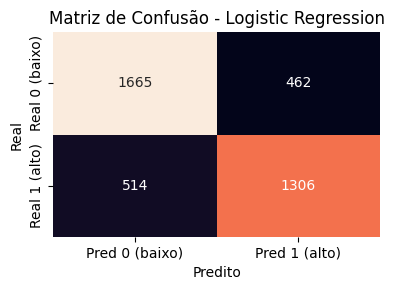

Erros classe 0 (baixo→alto): 462
Erros classe 1 (alto→baixo): 514
➡️ O modelo erra MAIS para ALTO consumo (classe 1).



In [ ]:
# avaliando Logistic Regression

avaliar_classificacao("Logistic Regression", y_test, y_pred_logreg)

=== Random Forest ===
Accuracy: 0.8964

Classification report:
              precision    recall  f1-score   support

           0     0.8973    0.9121    0.9046      2127
           1     0.8952    0.8780    0.8865      1820

    accuracy                         0.8964      3947
   macro avg     0.8963    0.8951    0.8956      3947
weighted avg     0.8964    0.8964    0.8963      3947



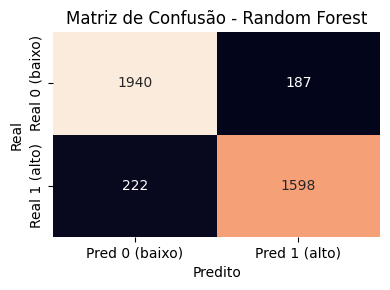

Erros classe 0 (baixo→alto): 187
Erros classe 1 (alto→baixo): 222
➡️ O modelo erra MAIS para ALTO consumo (classe 1).



In [ ]:
# avaliando Random Forest

avaliar_classificacao("Random Forest", y_test, y_pred_rf)

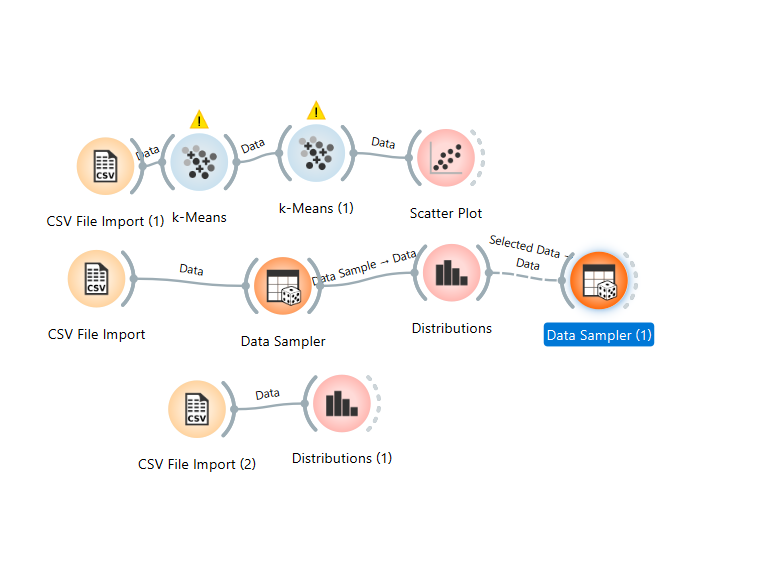

questões 36 até 40

36. Importação e visualização
Contagem observada: 2.075.259 registros e 9 variáveis no CSV File Import e no Data Table após a importação correta..

Status: dados sem metas e com as colunas reconhecidas; pode prosseguir para análise..

37. Amostragem 1%
Procedimento esperado: usar Sample Data com 1% e comparar Distribution de Global_active_power entre amostra e base; como a amostragem aleatória mantém a forma geral, a distribuição da amostra tende a ser semelhante à da base completa..

Conclusão com base no histograma geral: a forma é altamente concentrada em valores baixos, então uma amostra aleatória de 1% refletirá esse mesmo padrão de concentração..

38. Distribuição do consumo
Evidência: no widget Distributions para Global_active_power, o histograma mostra quase toda a massa em faixas baixas, com cauda muito pequena para valores altos..

Conclusão: o consumo está concentrado em valores baixos; há poucos registros de alto consumo..

39. Relação Voltage vs Global_active_power
Evidência: o Scatter Plot de Voltage (X) versus Global_active_power (Y) exibe nuvem ampla e dispersa, sem inclinação linear clara..

Conclusão: não há correlação linear visível relevante entre Voltage e Global_active_power..

40. k-Means com 3 clusters (Sub_metering_1/2/3)
Evidência: no Scatter Plot colorido por “Cluster”, as cores formam regiões distintas, separando pontos com consumo baixo geral, pontos com picos concentrados em um submedidor e um grupo intermediário/misto..

Conclusão: sim, cada cluster representa um padrão distinto de consumo doméstico por submedidor; a normalização e KMeans++ ajudam na estabilidade dessa separação..